---
title: "Density destructors"
short_title: "04 · Density destructors"
subtitle: "Naming the object: an invertible map that destroys structure, built by iterating whitening + a nonlinearity"
description: >
  The Inouye-Ravikumar density-destructor framing ties notebooks 00-03
  together: a normalizing flow is an invertible map whose pushforward is
  N(0, I). We build one the canonical way — alternate marginal Gaussianization
  (an elementwise nonlinearity) with a rotation — and watch two-moons morph
  into an isotropic Gaussian over rbig's iterations, then run the map backward
  to generate data.
---

(sec-nb-04)=
# 04 — Density destructors

Notebooks [00](00_change_of_variables.ipynb)–[03](03_why_standard_gaussian.ipynb)
assembled all the parts: an invertible map carries a density (change of
variables), maps compose with additive log-dets, the two directions trade off,
and $\mathcal{N}(0, I)$ is the natural target. Now we name the object those
parts describe — a **density destructor** — and build one explicitly.

**What you will see**

- The density-destructor definition (Inouye & Ravikumar, 2018) and how it
  unifies "normalizing flow", "Gaussianization", and "density destructor".
- The canonical recipe: alternate a **marginal Gaussianization** (elementwise
  nonlinearity) with a **rotation**, because neither move alone suffices.
- Two-moons morphing into $\mathcal{N}(0, I)$ across `rbig`'s iterations — the
  "intuition picture" for the whole method.
- Running the destructor *backward* to generate moon-shaped samples from
  Gaussian noise.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons

import rbig
from _style import style_ax

rng = np.random.default_rng(4)

X, _ = make_moons(6000, noise=0.05, random_state=0)
X = (X - X.mean(0)) / X.std(0)  # standardise so the base is N(0, I)

## 1. What is a density destructor?

Inouye & Ravikumar {cite}`inouye2018ddd` define a **density destructor** as an
invertible map $T:\mathbb{R}^d\to\mathbb{R}^d$ that turns the data distribution
into a fixed, structureless base — here the standard Gaussian:

$$
T_\# p_X = \mathcal{N}(0, I)
\qquad\Longleftrightarrow\qquad
z = T(x) \sim \mathcal{N}(0, I)\ \text{ when } x \sim p_X.
$$

It "destroys" the density: everything that made $p_X$ structured — skew, heavy
tails, multi-modality, dependence between coordinates — is removed, leaving
isotropic Gaussian noise. This is the *same object* the rest of the field calls
by other names, and each earlier notebook is one of its capabilities:

| once you have a destructor $T$ | you get… | from notebook |
|---|---|---|
| $\log p_X(x) = \log\mathcal{N}(T(x)) + \log\lvert\det J_T\rvert$ | exact density | [00](00_change_of_variables.ipynb), [01](01_composition_logdet.ipynb) |
| $x = T^{-1}(z),\ z\sim\mathcal{N}(0,I)$ | a generator | [02](02_forward_vs_inverse.ipynb) |
| $\mathrm{TC}(T(x)) = 0$, negentropy $=0$ | independent, IT-friendly coords | [03](03_why_standard_gaussian.ipynb) |

"Normalizing flow" (ML), "Gaussianization" (signal processing), and "density
destructor" (Inouye–Ravikumar) are three names for this one map. The whole
curriculum is about *building good ones*.

## 2. The canonical recipe: nonlinearity + rotation

How do we construct $T$ for a tangled distribution like two-moons? The classic
answer — Gaussianization {cite}`chenGopinath2000gauss` via Rotation-Based
Iterative Gaussianization (RBIG) {cite}`laparra2011rbig` — alternates two moves
that each fix what the other cannot:

1. **Marginal Gaussianization** — apply $z_i = \Phi^{-1}(F_i(x_i))$ to each
   coordinate independently. This makes every *axis* standard normal, but being
   elementwise it cannot touch the *dependence* between axes.
2. **Rotation** — apply an orthogonal $Q$. This is free ($\log|\det| = 0$,
   [notebook 01](01_composition_logdet.ipynb)) and mixes the axes, exposing new
   non-Gaussian structure along fresh directions for the next marginal step.

Neither alone works: marginals-only leaves the moons' dependence intact;
rotations-only never fixes the marginal shapes. Watch one iteration.

per-axis std after marginal step: [1. 1.] (each axis standardised)
the moon shape survives the marginal step — only the rotation can remix it


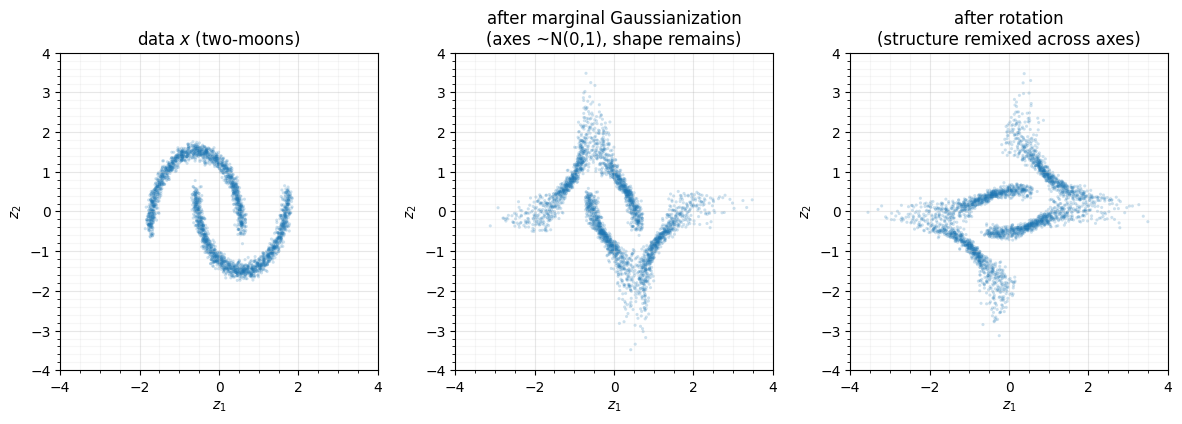

In [2]:
mg = rbig.MarginalGaussianize().fit(X)
X_marg = mg.transform(X)                      # step 1: elementwise nonlinearity
rot = rbig.RandomRotation(random_state=0).fit(X_marg)
X_rot = rot.transform(X_marg)                 # step 2: rotation

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, data, title in [
    (axes[0], X, "data $x$ (two-moons)"),
    (axes[1], X_marg, "after marginal Gaussianization\n(axes ~N(0,1), shape remains)"),
    (axes[2], X_rot, "after rotation\n(structure remixed across axes)"),
]:
    ax.scatter(data[:3000, 0], data[:3000, 1], s=5, alpha=0.22, edgecolors="none")
    ax.set(title=title, xlim=(-4, 4), ylim=(-4, 4), xlabel="$z_1$", ylabel="$z_2$")
    ax.set_aspect("equal")
    style_ax(ax)
fig.tight_layout()

print("per-axis std after marginal step:", X_marg.std(0).round(3),
      "(each axis standardised)")
print("the moon shape survives the marginal step — only the rotation can remix it")

After step 1 each axis is individually standard-normal, yet the crescent shape
is clearly still there — proof that elementwise maps cannot remove dependence.
Step 2 rotates that structure onto new axes, where it again looks non-Gaussian
*per coordinate* — so the next marginal step has something to bite on. One
`RBIGLayer` in `rbig` is exactly this `(marginal, rotation)` pair.

## 3. Iterate to convergence — the intuition picture

Stack many `(marginal, rotation)` layers and the distribution is ground down
toward $\mathcal{N}(0, I)$. `rbig.AnnealedRBIG` is precisely this iterated
destructor; we fit it and snapshot the data after $0, 3, 12,$ and all layers.

fitted 100 layers; final pushforward std = [1. 1.]


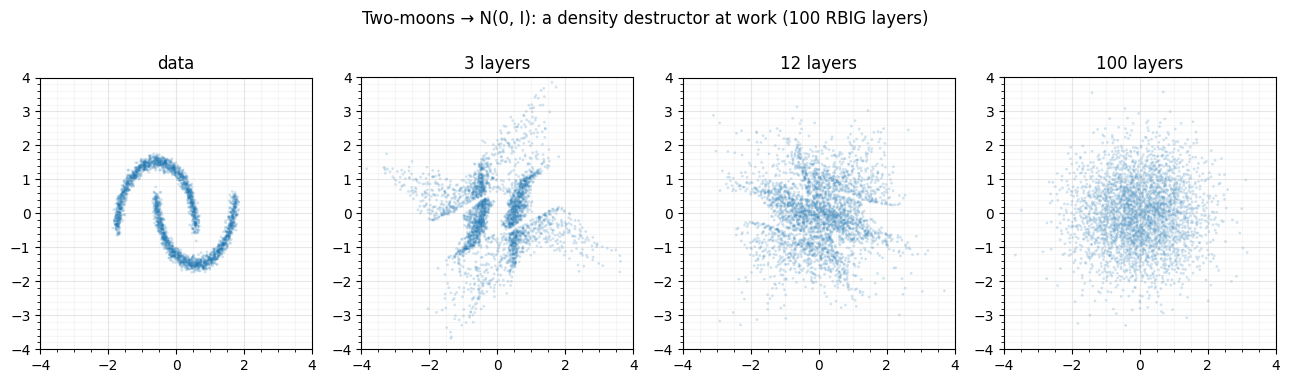

In [3]:
model = rbig.AnnealedRBIG(n_layers=100, rotation="random", random_state=0)
model.fit(X)


def through_layers(k):
    state = X
    for layer in model.layers_[:k]:
        state = layer.transform(state)
    return state


n_total = len(model.layers_)
fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))
for ax, k in zip(axes, [0, 3, 12, n_total]):
    d = through_layers(k)
    ax.scatter(d[:3000, 0], d[:3000, 1], s=4, alpha=0.2, edgecolors="none")
    label = "data" if k == 0 else f"{k} layers"
    ax.set(title=label, xlim=(-4, 4), ylim=(-4, 4))
    ax.set_aspect("equal")
    style_ax(ax)
fig.suptitle(f"Two-moons → N(0, I): a density destructor at work "
             f"({n_total} RBIG layers)", y=1.02)
fig.tight_layout()
print(f"fitted {n_total} layers; final pushforward std = "
      f"{through_layers(n_total).std(0).round(3)}")

The crescents are progressively destroyed: by the last layer the data is an
isotropic Gaussian blob with unit per-axis variance. That sequence *is*
Gaussianization — iterated whitening-plus-nonlinearity grinding structure away.
(How many layers are "enough" is a convergence question we quantify with
diagnostics in [notebook 06](06_gaussianity_diagnostics.ipynb).)

## 4. Run it backward to generate

Because a density destructor is invertible, $T^{-1}$ is a **generator**: draw
$z \sim \mathcal{N}(0, I)$ and push it back through the inverted layers to get
data-shaped samples. `rbig` does this with `model.sample`, which internally
inverts each marginal layer (the bisection/root-find of
[notebook 02](02_forward_vs_inverse.ipynb)) and transposes each rotation.

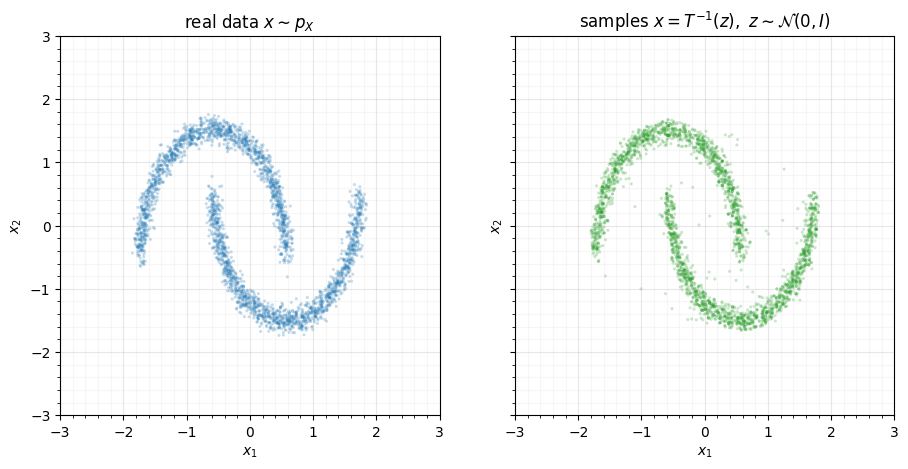

In [4]:
samples = np.asarray(model.sample(4000, random_state=1))

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.6), sharex=True, sharey=True)
axes[0].scatter(X[:3000, 0], X[:3000, 1], s=5, alpha=0.25, edgecolors="none")
axes[0].set(title="real data $x \\sim p_X$")
axes[1].scatter(samples[:3000, 0], samples[:3000, 1], s=5, alpha=0.25,
                edgecolors="none", color="tab:green")
axes[1].set(title=r"samples $x = T^{-1}(z),\ z\sim\mathcal{N}(0,I)$")
for ax in axes:
    ax.set(xlim=(-3, 3), ylim=(-3, 3), xlabel="$x_1$", ylabel="$x_2$")
    ax.set_aspect("equal")
    style_ax(ax)
fig.tight_layout()

The same map, read in reverse, turns Gaussian noise back into two moons. A good
density destructor is therefore simultaneously a **density estimator** (forward)
and a **generative model** (inverse) — one object, both jobs.

## Recap

| concept | statement | in code |
|---|---|---|
| density destructor | invertible $T$ with $T_\# p_X = \mathcal{N}(0,I)$ | `rbig.AnnealedRBIG` |
| one RBIG layer | marginal Gaussianization ∘ rotation | `MarginalGaussianize` + `RandomRotation` |
| why both moves | marginals fix axes; rotations remix dependence | §2 three-panel |
| iterate | structure ground down to $\mathcal{N}(0,I)$ | `model.layers_` snapshots |
| generate | run $T^{-1}$ on Gaussian draws | `model.sample` |

:::{note} Bridge to the packages
`rbig.AnnealedRBIG` is the classic *non-parametric* destructor (fit greedily,
layer by layer). The same construction as a *trainable* `flowjax` flow — the
Gaussianization-flow family {cite}`meng2020gaussflow` — is `gauss_flows.fit_rbig`
(greedy warm-start) and `gauss_flows.gaussianization_flow` (gradient-trained).
We build the parametric versions in [Parts 3–5](../).
:::

**Next up.** Iterating $\Phi^{-1}\circ F$ hundreds of times is a numerical
minefield — CDFs hit $0$ and $1$, $\Phi^{-1}$ blows up, log-dets must not drift.
[05 — Numerical mechanics](05_numerical_mechanics.ipynb) covers the jitter,
clamping, and float64 bookkeeping that keep a deep destructor stable.